# 🇰🇷 약 1M 파라미터 미니 BERT 사전학습

한국어 코퍼스로 **SentencePiece 토크나이저 → MLM·NSP 데이터셋 → 미니 BERT → 10 epoch 사전학습 → 평가·시각화**까지 한 번에 진행합니다.

이 노트북은 다음 평가 기준을 코드와 그래프로 직접 확인하도록 구성했습니다.

- 어휘 크기 약 **8,000**의 한국어 서브워드 토크나이저
- MLM: 전체 일반 토큰의 약 **15%**, 교체 비율 **80% `[MASK]` / 10% 랜덤 / 10% 유지**
- NSP: 실제 다음 문장과 무관한 문장을 **50:50**으로 구성
- 대용량 배열은 `np.memmap`, 구조와 샘플은 JSON/JSONL로 저장
- 약 **1M 파라미터**의 BERT를 직접 구현하고 **10 epoch** 학습
- MLM·NSP loss/accuracy, learning rate, 데이터 분포, 모델 크기 시각화

> 기본 설정은 과제 제출용입니다. 먼저 빠르게 점검할 때만 `QUICK_RUN=True`로 바꾸세요.

## 0. 실행 순서

위에서 아래로 차례대로 실행하면 됩니다. 각 코드 셀 바로 앞의 마크다운은 “왜 이 셀이 필요한가”를 설명합니다. 코드는 짧은 주석을 붙여 길을 잃지 않게 했습니다.

## 1. 필요한 라이브러리 설치

`sentencepiece`는 한국어 서브워드 토크나이저를 만들고, `torchinfo`는 모델 구조와 파라미터 수를 보기 좋게 보여줍니다.

In [1]:
# 필요한 도구만 가볍게 챙깁니다. 과한 짐은 내려놓기! 🎒
%pip install -q sentencepiece torchinfo tqdm requests


Note: you may need to restart the kernel to use updated packages.


## 2. 라이브러리와 재현성 설정

난수 씨앗을 고정하면 같은 코퍼스와 설정에서 데이터 구성과 학습 흐름을 다시 확인하기 쉽습니다.

In [2]:
from __future__ import annotations

import contextlib
import json
import math
import os
import random
import re
import shutil
import zipfile
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 실험이 매번 산책 나가지 않도록 씨앗을 단단히 심습니다. 🌱
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())

PyTorch: 2.7.1+cu118
CUDA 사용 가능: True


## 3. 프로젝트 설정

미니 BERT의 핵심 크기는 `hidden_size=96`, encoder 2층, attention head 4개입니다. 단어 임베딩을 MLM 출력층과 공유하여 전체 학습 파라미터가 약 1M이 되도록 설계했습니다.

In [3]:
@dataclass
class ProjectConfig:
    # 데이터 설정
    vocab_size: int = 8_000
    max_seq_len: int = 128
    max_documents: int = 50_000
    train_examples: int = 100_000
    valid_examples: int = 10_000
    valid_ratio: float = 0.10

    # 약 1M BERT 설정
    hidden_size: int = 96
    num_heads: int = 4
    num_layers: int = 2
    intermediate_size: int = 192
    dropout: float = 0.10

    # 학습 설정
    batch_size: int = 64
    epochs: int = 10
    learning_rate: float = 3e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.10
    grad_clip: float = 1.0

    # 디버깅 스위치
    quick_run: bool = False

CFG = ProjectConfig()
CFG.quick_run = os.getenv("MINI_BERT_QUICK_RUN", "0") == "1"

# 빠른 시운전 모드: 엔진 소리만 듣고 바로 출발 여부를 판단합니다. 🛵
if CFG.quick_run:
    CFG.max_documents = 300
    CFG.train_examples = 64
    CFG.valid_examples = 16
    CFG.max_seq_len = 64
    CFG.batch_size = 8
    CFG.epochs = 1

BASE_DIR = Path("/content/mini_bert_project") if Path("/content").exists() else Path.cwd() / "mini_bert_project"
DATA_DIR = BASE_DIR / "data"
TOKENIZER_DIR = BASE_DIR / "tokenizer"
MEMMAP_DIR = BASE_DIR / "memmap"
MODEL_DIR = BASE_DIR / "models"
RESULT_DIR = BASE_DIR / "results"

for directory in [DATA_DIR, TOKENIZER_DIR, MEMMAP_DIR, MODEL_DIR, RESULT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("작업 폴더:", BASE_DIR)
print("학습 장치:", DEVICE)
print(CFG)

작업 폴더: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project
학습 장치: cuda
ProjectConfig(vocab_size=8000, max_seq_len=128, max_documents=50000, train_examples=100000, valid_examples=10000, valid_ratio=0.1, hidden_size=96, num_heads=4, num_layers=2, intermediate_size=192, dropout=0.1, batch_size=64, epochs=10, learning_rate=0.0003, weight_decay=0.01, warmup_ratio=0.1, grad_clip=1.0, quick_run=False)


## 4. 한국어 Wikipedia 고속 코퍼스 생성

문서별 Wikipedia API 호출 대신, Hugging Face가 미리 정제해 둔 한국어 Wikipedia **Parquet 파일을 묶음 단위로 다운로드**합니다.

- 수만 번의 API 왕복을 없애 다운로드 병목을 줄입니다.
- `datasets`와 `pyarrow`는 사용하지 않습니다.
- 독립적인 `DuckDB`로 필요한 50,000개 문서만 읽습니다.
- 다운로드와 변환이 끊기면 파일 크기와 상태 기록을 이용해 이어받습니다.
- 문서 사이에 빈 줄을 넣어 NSP 문서 경계를 유지합니다.

> 기존의 느린 `.part` 파일은 사용하지 않으며, 새로운 고속 다운로드용 임시 파일을 별도로 관리합니다.


In [5]:
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
from pathlib import Path

import requests
from requests.adapters import HTTPAdapter
from tqdm.auto import tqdm
from urllib3.util.retry import Retry


# ---------------------------------------------------------
# 1. DuckDB만 준비하기
# ---------------------------------------------------------

# DuckDB는 Parquet를 직접 읽습니다. pyarrow와는 각자의 길을 갑니다. 🦆
try:
    import duckdb
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--no-deps",
        "duckdb>=1.1.0",
    ])
    import duckdb


# ---------------------------------------------------------
# 2. 경로와 수집 설정
# ---------------------------------------------------------

CORPUS_PATH = DATA_DIR / "kowiki.txt"
FAST_TEMP_PATH = DATA_DIR / "kowiki.fast.part"
FAST_STATE_PATH = DATA_DIR / "kowiki_fast_state.json"
PARQUET_DIR = DATA_DIR / "kowiki_parquet_cache"
PARQUET_DIR.mkdir(parents=True, exist_ok=True)

MAX_ARTICLES = int(CFG.max_documents)
OVERWRITE = False
KEEP_PARQUET_CACHE = False

DATASET_NAME = "wikimedia/wikipedia"
DATASET_CONFIG = "20231101.ko"
DATASET_SPLIT = "train"

# Dataset Viewer 대신 저장소 파일 목록 API를 사용합니다.
REPO_INFO_URL = (
    f"https://huggingface.co/api/datasets/{DATASET_NAME}"
)

REPO_RESOLVE_URL = (
    f"https://huggingface.co/datasets/{DATASET_NAME}/resolve/main"
)

USER_AGENT = (
    "MiniBERT-Korean-Pretrain/2.0 "
    "(educational corpus builder; contact: local-notebook)"
)

print("최종 코퍼스:", CORPUS_PATH)
print(f"수집 목표: {MAX_ARTICLES:,}개 문서")
print("수집 방식: Hugging Face Parquet + DuckDB")


# ---------------------------------------------------------
# 3. 재시도 가능한 HTTP 세션
# ---------------------------------------------------------

def make_session() -> requests.Session:
    """잠깐의 네트워크 삐끗은 자동으로 다시 붙잡습니다."""
    retry = Retry(
        total=6,
        connect=6,
        read=6,
        backoff_factor=1.0,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset({"GET"}),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=4, pool_maxsize=4)
    session = requests.Session()
    session.mount("https://", adapter)
    session.headers.update({
        "User-Agent": USER_AGENT,
        "Accept": "application/json, application/octet-stream;q=0.9, */*;q=0.8",
        "Accept-Encoding": "gzip, deflate",
    })
    return session


SESSION = make_session()


def get_parquet_urls() -> list[str]:
    """
    Hugging Face 저장소 파일 목록에서
    한국어 Wikipedia Parquet 파일을 직접 찾습니다.
    """

    from urllib.parse import quote

    response = SESSION.get(
        REPO_INFO_URL,
        params={"blobs": "false"},
        timeout=(20, 180),
    )
    response.raise_for_status()

    payload = response.json()
    siblings = payload.get("siblings", [])

    # 저장소에 등록된 모든 파일 경로를 꺼냅니다.
    repository_paths = []

    for item in siblings:
        path = item.get("rfilename") or item.get("path")

        if path:
            repository_paths.append(str(path))

    # Parquet 파일만 골라냅니다. 돌멩이 속 오리 찾기! 🦆
    parquet_paths = [
        path
        for path in repository_paths
        if path.lower().endswith(".parquet")
    ]

    if not parquet_paths:
        raise RuntimeError(
            "저장소에서 Parquet 파일을 찾지 못했습니다."
        )

    # 지정한 한국어 설정이 경로 어디에 있든 찾습니다.
    selected_config = DATASET_CONFIG

    selected_paths = [
        path
        for path in parquet_paths
        if selected_config in path.split("/")
    ]

    # 지정한 날짜가 없다면 가장 최신 한국어 설정을 자동 선택합니다.
    if not selected_paths:
        korean_configs = sorted({
            segment
            for path in parquet_paths
            for segment in path.split("/")
            if re.fullmatch(r"\d{8}\.ko", segment)
        })

        if not korean_configs:
            raise RuntimeError(
                "한국어 Wikipedia Parquet 설정을 찾지 못했습니다.\n"
                f"전체 Parquet 파일 수: {len(parquet_paths):,}"
            )

        selected_config = korean_configs[-1]

        selected_paths = [
            path
            for path in parquet_paths
            if selected_config in path.split("/")
        ]

        print(
            f"요청한 {DATASET_CONFIG} 설정이 없어 "
            f"{selected_config} 설정을 사용합니다."
        )

    # train split 파일만 우선 선택합니다.
    train_paths = [
        path
        for path in selected_paths
        if (
            "train" in Path(path).name.lower()
            or "train" in [
                part.lower()
                for part in Path(path).parts
            ]
        )
    ]

    if train_paths:
        selected_paths = train_paths

    selected_paths = sorted(set(selected_paths))

    # 실제 다운로드 가능한 resolve 주소로 변환합니다.
    urls = [
        (
            f"{REPO_RESOLVE_URL}/"
            f"{quote(path, safe='/')}?download=true"
        )
        for path in selected_paths
    ]

    print(f"선택된 설정: {selected_config}")
    print(f"발견한 Parquet 조각: {len(urls):,}개")

    if not urls:
        raise RuntimeError(
            "다운로드할 한국어 Parquet 파일이 없습니다."
        )

    return urls


# ---------------------------------------------------------
# 4. 이어받기 가능한 대용량 파일 다운로드
# ---------------------------------------------------------

def download_with_resume(url: str, save_path: Path) -> None:
    """중간 파일이 있으면 받은 위치부터 이어서 다운로드합니다."""
    existing_size = save_path.stat().st_size if save_path.exists() else 0
    headers = {"Range": f"bytes={existing_size}-"} if existing_size else {}

    response = SESSION.get(
        url,
        headers=headers,
        stream=True,
        timeout=(30, 300),
        allow_redirects=True,
    )

    if response.status_code == 416:
        print(f"이미 다운로드된 조각입니다: {save_path.name}")
        return

    response.raise_for_status()

    # 206은 이어받기, 200은 서버가 Range를 무시했으므로 처음부터 씁니다.
    if existing_size and response.status_code == 206:
        mode = "ab"
        initial = existing_size
    else:
        mode = "wb"
        initial = 0

    incoming = int(response.headers.get("content-length", 0))
    total = initial + incoming if incoming else None

    with save_path.open(mode) as file, tqdm(
        total=total,
        initial=initial,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
        desc=f"Parquet {save_path.stem}",
    ) as bar:
        for chunk in response.iter_content(chunk_size=4 * 1024 * 1024):
            if not chunk:
                continue
            file.write(chunk)
            bar.update(len(chunk))

    if save_path.stat().st_size == 0:
        raise RuntimeError(f"빈 Parquet 파일이 저장되었습니다: {save_path}")


# ---------------------------------------------------------
# 5. 문서 정리와 상태 저장
# ---------------------------------------------------------

SPACE_RE_FAST = re.compile(r"\s+")


def clean_article_lines(title: str, text: str) -> list[str]:
    """제목과 본문을 BERT가 읽기 좋은 줄로 다듬습니다."""
    lines = []

    title = SPACE_RE_FAST.sub(" ", str(title)).strip()
    if len(title) >= 2:
        lines.append(title)

    for raw_line in str(text).splitlines():
        line = SPACE_RE_FAST.sub(" ", raw_line).strip()
        if len(line) >= 10:
            lines.append(line)

    return lines


def load_fast_state() -> dict:
    default = {
        "shard_index": 0,
        "row_offset": 0,
        "article_count": 0,
        "byte_offset": 0,
    }

    if not FAST_STATE_PATH.exists() or not FAST_TEMP_PATH.exists():
        return default

    try:
        state = json.loads(FAST_STATE_PATH.read_text(encoding="utf-8"))
        return {key: int(state.get(key, value)) for key, value in default.items()}
    except (OSError, ValueError, TypeError, json.JSONDecodeError):
        return default


def save_fast_state(state: dict) -> None:
    """작은 이정표는 임시 파일로 쓴 뒤 원자적으로 교체합니다."""
    temp_state = FAST_STATE_PATH.with_suffix(".json.tmp")
    temp_state.write_text(
        json.dumps(state, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    os.replace(temp_state, FAST_STATE_PATH)


# ---------------------------------------------------------
# 6. Parquet에서 필요한 문서만 추출
# ---------------------------------------------------------

if OVERWRITE:
    for old_path in (CORPUS_PATH, FAST_TEMP_PATH, FAST_STATE_PATH):
        old_path.unlink(missing_ok=True)

if CORPUS_PATH.exists() and CORPUS_PATH.stat().st_size > 0:
    print("이미 완성된 kowiki.txt가 있어 생성을 건너뜁니다. ♻️")

else:
    parquet_urls = get_parquet_urls()
    state = load_fast_state()

    # 마지막으로 안전하게 기록된 바이트 뒤의 찌꺼기는 잘라냅니다.
    if FAST_TEMP_PATH.exists():
        with FAST_TEMP_PATH.open("r+b") as file:
            file.truncate(state["byte_offset"])

    article_count = state["article_count"]
    shard_start = state["shard_index"]

    print(f"Parquet 조각 수: {len(parquet_urls):,}")
    if article_count:
        print(f"{article_count:,}개 문서 다음부터 이어받습니다. 🧵")

    connection = duckdb.connect(database=":memory:")

    with FAST_TEMP_PATH.open("ab") as output_file:
        progress = tqdm(
            total=MAX_ARTICLES,
            initial=article_count,
            desc="한국어 위키 문서 변환",
            unit="문서",
        )

        for shard_index in range(shard_start, len(parquet_urls)):
            if article_count >= MAX_ARTICLES:
                break

            parquet_path = PARQUET_DIR / f"kowiki_{shard_index:04d}.parquet"
            download_with_resume(parquet_urls[shard_index], parquet_path)

            row_offset = state["row_offset"] if shard_index == shard_start else 0
            remaining = MAX_ARTICLES - article_count

            # 전체 파일을 DataFrame으로 펼치지 않고 작은 묶음만 꺼냅니다. 메모리 평화 조약! 🕊️
            cursor = connection.execute(
                """
                SELECT title, text
                FROM read_parquet(?)
                LIMIT ? OFFSET ?
                """,
                [str(parquet_path), int(remaining), int(row_offset)],
            )

            rows_read_in_shard = row_offset

            while article_count < MAX_ARTICLES:
                rows = cursor.fetchmany(512)
                if not rows:
                    break

                for title, text in rows:
                    lines = clean_article_lines(title, text)
                    rows_read_in_shard += 1

                    if len(lines) < 2:
                        continue

                    article_bytes = ("\n".join(lines) + "\n\n").encode("utf-8")
                    output_file.write(article_bytes)
                    article_count += 1
                    progress.update(1)

                    if article_count >= MAX_ARTICLES:
                        break

                output_file.flush()
                byte_offset = output_file.tell()

                state = {
                    "shard_index": shard_index,
                    "row_offset": rows_read_in_shard,
                    "article_count": article_count,
                    "byte_offset": byte_offset,
                }
                save_fast_state(state)

            # 이 조각을 끝냈다면 다음 조각의 0번째 행부터 시작합니다.
            state = {
                "shard_index": shard_index + 1,
                "row_offset": 0,
                "article_count": article_count,
                "byte_offset": output_file.tell(),
            }
            save_fast_state(state)

            if not KEEP_PARQUET_CACHE:
                parquet_path.unlink(missing_ok=True)

        progress.close()

    connection.close()

    if article_count < MAX_ARTICLES:
        raise RuntimeError(
            f"요청한 {MAX_ARTICLES:,}개 중 {article_count:,}개만 저장했습니다."
        )

    os.replace(FAST_TEMP_PATH, CORPUS_PATH)
    FAST_STATE_PATH.unlink(missing_ok=True)

    if not KEEP_PARQUET_CACHE:
        try:
            PARQUET_DIR.rmdir()
        except OSError:
            pass

    print("\n한국어 Wikipedia 코퍼스 생성 완료! 🎉")
    print(f"저장 문서 수: {article_count:,}")
    print(f"파일 크기: {CORPUS_PATH.stat().st_size / 1024**2:,.1f} MB")


# ---------------------------------------------------------
# 7. 결과 미리보기
# ---------------------------------------------------------

if not CORPUS_PATH.exists() or CORPUS_PATH.stat().st_size == 0:
    raise RuntimeError("kowiki.txt 생성에 실패했습니다.")

print("\n코퍼스 앞부분")
print("=" * 70)
with CORPUS_PATH.open("r", encoding="utf-8", errors="ignore") as file:
    for _ in range(18):
        line = file.readline()
        if not line:
            break
        print(line.rstrip())


최종 코퍼스: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/data/kowiki.txt
수집 목표: 50,000개 문서
수집 방식: Hugging Face Parquet + DuckDB
선택된 설정: 20231101.ko
발견한 Parquet 조각: 3개
Parquet 조각 수: 3


한국어 위키 문서 변환:   0%|          | 0/50000 [00:00<?, ?문서/s]

Parquet kowiki_0000:   0%|          | 0.00/381M [00:00<?, ?B/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Parquet kowiki_0001:   0%|          | 0.00/196M [00:00<?, ?B/s]


한국어 Wikipedia 코퍼스 생성 완료! 🎉
저장 문서 수: 50,000
파일 크기: 229.7 MB

코퍼스 앞부분
지미 카터
제임스 얼 카터 주니어(, 1924년 10월 1일~)는 민주당 출신 미국의 제39대 대통령(1977년~1981년)이다.
지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다.
조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.
1962년 조지아주 상원 의원 선거에서 낙선하였으나, 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주지사 선거에 낙선하지만, 1970년 조지아 주지사 선거에서 당선됐다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.
1976년 미합중국 제39대 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워서, 많은 지지를 받았는데 제럴드 포드 대통령을 누르고 당선되었다.
카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.
카터는 이집트와 이스라엘을 조정하여 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다. 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 그러나 1979년, 양국 간의 평화조약이 백악관에서 이루어졌다.
소련과 제2차 전략 무기 제한 협상(SALT II)에 조인했다.
카터는 1970년대 후반 당시 대한민국 등 인권 후진국의 국민들의 인권을 지키기 위해 노력했으며, 취임 이후 계속해서 도덕정치를 내세웠다.
임기 말, 소련의 아프가니스탄 침공 사건으로 인해 1980년 하계 올림픽에 반공국가들의 보이콧을 하였다.
그는 주이란 미국 대사관 인질 사건의 인질 구출 

## 5. 생성된 한국어 코퍼스 확인

앞 셀에서 만든 `mini_bert_project/data/kowiki.txt`를 확인합니다.
직접 준비한 코퍼스가 있다면 아래 후보 경로 중 한 곳에 두어도 자동으로 찾습니다.

- `/content/kowiki.txt`
- `/content/data/kowiki.txt`
- 현재 프로젝트의 `data/kowiki.txt`


In [6]:
def find_corpus() -> Path:
    """한국어 텍스트 코퍼스를 찾아 프로젝트 폴더로 연결합니다."""
    candidates = [
        DATA_DIR / "kowiki.txt",
        Path("/content/data/kowiki.txt"),
        Path("/content/kowiki.txt"),
        Path.cwd() / "data" / "kowiki.txt",
        Path.cwd() / "kowiki.txt",
    ]
    for path in candidates:
        if path.exists():
            return path

    # ZIP만 보여도 당황하지 않습니다. 압축 지퍼를 열어봅니다. 🧳
    zip_candidates = [
        DATA_DIR / "kowiki.txt.zip",
        Path("/content/kowiki.txt.zip"),
        Path("/content/data/kowiki.txt.zip"),
        Path.cwd() / "kowiki.txt.zip",
    ]
    for zip_path in zip_candidates:
        if zip_path.exists():
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(DATA_DIR)
            extracted = DATA_DIR / "kowiki.txt"
            if extracted.exists():
                return extracted

    raise FileNotFoundError(
        "kowiki.txt를 찾지 못했습니다. 한국어 코퍼스를 /content/data/kowiki.txt "
        "또는 mini_bert_project/data/kowiki.txt 위치에 넣어주세요."
    )

CORPUS_PATH = find_corpus()
print("코퍼스:", CORPUS_PATH)
print(f"파일 크기: {CORPUS_PATH.stat().st_size / 1024**2:,.1f} MB")

코퍼스: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/data/kowiki.txt
파일 크기: 229.7 MB


## 6. SentencePiece BPE 토크나이저 학습

특수 토큰은 `[PAD]`, `[UNK]`, `[BOS]`, `[EOS]`, `[SEP]`, `[CLS]`, `[MASK]`를 포함합니다. 이미 토크나이저가 있으면 재사용하므로 두 번째 실행부터는 빠릅니다.

In [7]:
# 8천 개 조각으로 한국어 레고 상자를 준비합니다. 🧱
TOKENIZER_PREFIX = TOKENIZER_DIR / "ko_8000"
TOKENIZER_MODEL = TOKENIZER_PREFIX.with_suffix(".model")

if not TOKENIZER_MODEL.exists():
    print("토크나이저 학습 시작: 한국어 조각 퍼즐을 만드는 중입니다. 🧩")
    spm.SentencePieceTrainer.train(
        input=str(CORPUS_PATH),
        model_prefix=str(TOKENIZER_PREFIX),
        vocab_size=CFG.vocab_size,
        model_type="bpe",
        character_coverage=0.9995,
        input_sentence_size=2_000_000,
        shuffle_input_sentence=True,
        max_sentence_length=16_384,
        num_threads=max(1, min(8, os.cpu_count() or 1)),
        pad_id=0,
        pad_piece="[PAD]",
        unk_id=1,
        unk_piece="[UNK]",
        bos_id=2,
        bos_piece="[BOS]",
        eos_id=3,
        eos_piece="[EOS]",
        user_defined_symbols=["[SEP]", "[CLS]", "[MASK]"],
        hard_vocab_limit=False,
    )
else:
    print("기존 토크나이저를 재사용합니다. 재활용도 실력입니다. ♻️")

SP = spm.SentencePieceProcessor(model_file=str(TOKENIZER_MODEL))
print("실제 vocab size:", SP.get_piece_size())

토크나이저 학습 시작: 한국어 조각 퍼즐을 만드는 중입니다. 🧩


I0000 00:00:1784092166.821670     773 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/data/kowiki.txt
  input_format: 
  model_prefix: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/tokenizer/ko_8000
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 2000000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 16384
  num_threads: 4
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [SEP]
  user_defined_symbols: [CLS]
  user_defined_symbols: [MASK]
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_l

실제 vocab size: 8000


## 7. 특수 토큰과 토큰화 결과 확인

특수 토큰 ID를 코드에서 직접 조회해 순서 가정에 의존하지 않습니다. 한국어 문장이 어떤 서브워드 조각으로 나뉘는지도 확인합니다.

In [8]:
# 특수 토큰의 좌석 번호를 직접 확인합니다. 추측은 출입 금지! 🎟️
SPECIAL_IDS = {
    "pad": SP.piece_to_id("[PAD]"),
    "unk": SP.piece_to_id("[UNK]"),
    "bos": SP.piece_to_id("[BOS]"),
    "eos": SP.piece_to_id("[EOS]"),
    "sep": SP.piece_to_id("[SEP]"),
    "cls": SP.piece_to_id("[CLS]"),
    "mask": SP.piece_to_id("[MASK]"),
}
SPECIAL_ID_SET = set(SPECIAL_IDS.values())
NORMAL_TOKEN_IDS = np.array(
    [idx for idx in range(SP.get_piece_size()) if idx not in SPECIAL_ID_SET],
    dtype=np.int32,
)

sample_text = "작고 야무진 미니 버트가 한국어 문장을 차근차근 배웁니다."
sample_ids = SP.encode(sample_text, out_type=int)

print("특수 토큰 ID:", SPECIAL_IDS)
print("원문:", sample_text)
print("토큰:", SP.id_to_piece(sample_ids))
print("복원:", SP.decode(sample_ids))

특수 토큰 ID: {'pad': 0, 'unk': 1, 'bos': 2, 'eos': 3, 'sep': 4, 'cls': 5, 'mask': 6}
원문: 작고 야무진 미니 버트가 한국어 문장을 차근차근 배웁니다.
토큰: ['▁작', '고', '▁야', '무', '진', '▁미', '니', '▁버', '트가', '▁한국어', '▁문', '장을', '▁차', '근', '차', '근', '▁배', '웁', '니다', '.']
복원: 작고 야무진 미니 버트가 한국어 문장을 차근차근 배웁니다.


## 8. 코퍼스를 문서와 문장으로 정리

NSP는 “같은 문서에서 실제로 이어지는 문장”이 필요합니다. 따라서 빈 줄을 문서 경계로 보고 문장을 나눕니다. 문서 경계가 거의 없는 코퍼스라면 여러 줄을 묶는 안전장치도 사용합니다.

In [9]:
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?。！？])\s+")
SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """지나친 공백을 정리하고 빈 껍데기를 버립니다."""
    return SPACE_RE.sub(" ", text).strip()


def split_sentences(paragraph: str, min_chars: int = 8) -> List[str]:
    """문장부호를 기준으로 문장을 나눕니다."""
    parts = [clean_text(x) for x in SENTENCE_SPLIT_RE.split(paragraph)]
    return [x for x in parts if len(x) >= min_chars]


def load_documents(path: Path, max_documents: int) -> List[List[str]]:
    documents: List[List[str]] = []
    current_lines: List[str] = []
    non_empty_lines: List[str] = []

    def flush_document() -> None:
        nonlocal current_lines
        if not current_lines:
            return
        paragraph = clean_text(" ".join(current_lines))
        sentences = split_sentences(paragraph)
        if len(sentences) >= 2:
            documents.append(sentences)
        current_lines = []

    with path.open("r", encoding="utf-8", errors="ignore") as file:
        for raw_line in tqdm(file, desc="코퍼스 읽기"):
            line = clean_text(raw_line)
            if line:
                current_lines.append(line)
                non_empty_lines.append(line)
            else:
                flush_document()
                if len(documents) >= max_documents:
                    break
        flush_document()

    # 문서 경계가 거의 없으면 8줄씩 묶어 NSP용 문서를 다시 만듭니다. 🧱
    if len(documents) < 10:
        documents = []
        for start in range(0, len(non_empty_lines), 8):
            paragraph = " ".join(non_empty_lines[start:start + 8])
            sentences = split_sentences(paragraph)
            if len(sentences) >= 2:
                documents.append(sentences)
            if len(documents) >= max_documents:
                break

    if len(documents) < 4:
        raise ValueError("NSP를 만들 문서가 너무 적습니다. 빈 줄 또는 문장부호가 포함된 코퍼스를 확인하세요.")
    return documents[:max_documents]


DOCUMENTS = load_documents(CORPUS_PATH, CFG.max_documents)
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(DOCUMENTS))
valid_count = max(2, int(len(DOCUMENTS) * CFG.valid_ratio))
valid_indices = indices[:valid_count]
train_indices = indices[valid_count:]

TRAIN_DOCS = [DOCUMENTS[i] for i in train_indices]
VALID_DOCS = [DOCUMENTS[i] for i in valid_indices]

print(f"전체 문서: {len(DOCUMENTS):,}")
print(f"train 문서: {len(TRAIN_DOCS):,}")
print(f"valid 문서: {len(VALID_DOCS):,}")

코퍼스 읽기: 0it [00:00, ?it/s]

전체 문서: 48,157
train 문서: 43,342
valid 문서: 4,815


## 9. 코퍼스 통계 시각화

문서당 문장 수와 문장 길이를 확인하면 지나치게 짧거나 긴 데이터가 학습을 흔드는지 빠르게 알 수 있습니다.

,항목,값
0,문서 수,48157.000000
1,문서당 평균 문장,31.117055
2,문장 평균 글자,62.465365
3,문장 글자 중앙값,49.000000


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/

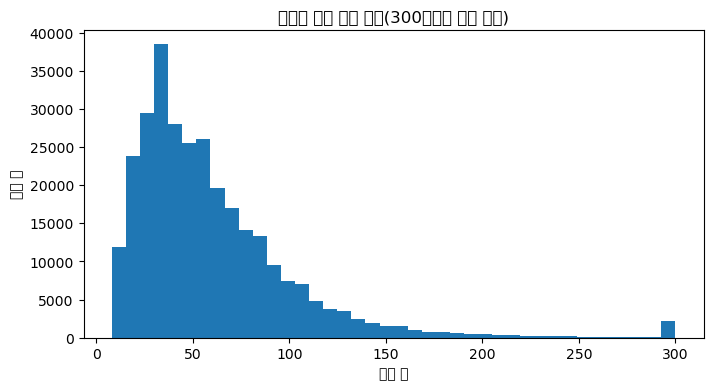

In [10]:
# 코퍼스의 체형을 그래프로 건강검진합니다. 🩺
doc_sentence_counts = np.array([len(doc) for doc in DOCUMENTS])
char_lengths = np.array([len(sentence) for doc in DOCUMENTS[:5_000] for sentence in doc])

stats = pd.DataFrame({
    "항목": ["문서 수", "문서당 평균 문장", "문장 평균 글자", "문장 글자 중앙값"],
    "값": [len(DOCUMENTS), doc_sentence_counts.mean(), char_lengths.mean(), np.median(char_lengths)],
})
display(stats)

plt.figure(figsize=(8, 4))
plt.hist(np.clip(char_lengths, 0, 300), bins=40)
plt.title("한국어 문장 길이 분포(300자에서 절단 표시)")
plt.xlabel("글자 수")
plt.ylabel("문장 수")
plt.show()

## 10. MLM용 Whole Word Masking 구현

SentencePiece에서 `▁`는 새 단어의 시작을 뜻합니다. 같은 단어에 속한 서브워드를 한 묶음으로 마스킹하여 모델이 지나치게 쉬운 힌트를 보지 않게 합니다.

선택된 토큰은 다음 규칙을 따릅니다.

- 80%: `[MASK]`
- 10%: 임의의 일반 토큰
- 10%: 원래 토큰 유지

In [11]:
def truncate_pair(
    tokens_a: List[int],
    tokens_b: List[int],
    max_pair_length: int,
    rng: np.random.Generator,
) -> None:
    """두 문장의 합이 길면 긴 쪽부터 살짝 다듬습니다."""
    while len(tokens_a) + len(tokens_b) > max_pair_length:
        target = tokens_a if len(tokens_a) > len(tokens_b) else tokens_b
        if rng.random() < 0.5:
            target.pop(0)
        else:
            target.pop()


def whole_word_candidates(input_ids: Sequence[int]) -> List[List[int]]:
    """같은 한국어 단어 조각을 한 팀으로 묶습니다."""
    groups: List[List[int]] = []
    for index, token_id in enumerate(input_ids):
        if token_id in SPECIAL_ID_SET:
            continue
        piece = SP.id_to_piece(int(token_id))
        if groups and not piece.startswith("▁"):
            groups[-1].append(index)
        else:
            groups.append([index])
    return groups


def apply_mlm(
    input_ids: Sequence[int],
    rng: np.random.Generator,
    mlm_probability: float = 0.15,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, int]]:
    """Whole Word Masking과 80·10·10 규칙을 적용합니다."""
    masked_ids = np.asarray(input_ids, dtype=np.int32).copy()
    labels = np.full(len(input_ids), -100, dtype=np.int32)
    candidates = whole_word_candidates(input_ids)
    rng.shuffle(candidates)

    normal_count = sum(len(group) for group in candidates)
    target_count = max(1, int(round(normal_count * mlm_probability)))
    selected: List[int] = []

    for group in candidates:
        if len(selected) >= target_count:
            break
        if selected and len(selected) + len(group) > target_count:
            continue
        selected.extend(group)

    # 첫 단어가 너무 길어도 최소 한 문제는 냅니다. 시험지 백지는 금지! 📝
    if not selected and candidates:
        selected.extend(candidates[0])

    replace_stats = {"mask": 0, "random": 0, "keep": 0}
    for index in selected:
        original_id = int(masked_ids[index])
        labels[index] = original_id
        dice = rng.random()
        if dice < 0.80:
            masked_ids[index] = SPECIAL_IDS["mask"]
            replace_stats["mask"] += 1
        elif dice < 0.90:
            masked_ids[index] = int(rng.choice(NORMAL_TOKEN_IDS))
            replace_stats["random"] += 1
        else:
            replace_stats["keep"] += 1

    replace_stats["selected"] = len(selected)
    replace_stats["normal"] = normal_count
    return masked_ids, labels, replace_stats

## 11. NSP 문장 쌍과 최종 입력 구성

양성 NSP는 같은 문서의 실제 다음 문장, 음성 NSP는 다른 문서의 무관한 문장을 사용합니다. 입력은 `[CLS] A [SEP] B [SEP]`이고 segment ID는 A에 0, B에 1을 부여합니다.

In [12]:
# 진짜 다음 문장과 가짜 다음 문장을 정성껏 섞습니다. 🃏
def random_sentence_from_other_document(
    documents: Sequence[Sequence[str]],
    current_doc_index: int,
    rng: np.random.Generator,
) -> str:
    """현재 문서와 다른 곳에서 음성 NSP 문장을 데려옵니다."""
    other_index = int(rng.integers(0, len(documents) - 1))
    if other_index >= current_doc_index:
        other_index += 1
    other_doc = documents[other_index]
    return other_doc[int(rng.integers(0, len(other_doc)))]


def encode_pretrain_example(
    sentence_a: str,
    sentence_b: str,
    nsp_label: int,
    rng: np.random.Generator,
) -> Dict[str, np.ndarray | Dict[str, int]]:
    """문장 쌍을 BERT가 먹을 수 있는 한 그릇으로 담습니다."""
    tokens_a = SP.encode(sentence_a, out_type=int)
    tokens_b = SP.encode(sentence_b, out_type=int)
    truncate_pair(tokens_a, tokens_b, CFG.max_seq_len - 3, rng)

    input_ids = [SPECIAL_IDS["cls"]] + tokens_a + [SPECIAL_IDS["sep"]] + tokens_b + [SPECIAL_IDS["sep"]]
    token_type_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    masked_ids, mlm_labels, mask_stats = apply_mlm(input_ids, rng)
    pad_length = CFG.max_seq_len - len(masked_ids)

    masked_ids = np.pad(masked_ids, (0, pad_length), constant_values=SPECIAL_IDS["pad"])
    token_type_ids = np.pad(np.asarray(token_type_ids, dtype=np.int8), (0, pad_length), constant_values=0)
    mlm_labels = np.pad(mlm_labels, (0, pad_length), constant_values=-100)

    return {
        "input_ids": masked_ids.astype(np.int32),
        "token_type_ids": token_type_ids.astype(np.int8),
        "mlm_labels": mlm_labels.astype(np.int32),
        "nsp_label": np.int8(nsp_label),
        "mask_stats": mask_stats,
    }

## 12. MLM·NSP 데이터 품질 미리 점검

본 데이터셋을 만들기 전에 작은 표본으로 마스킹 비율, 80·10·10 교체 비율, NSP 균형을 확인합니다. 데이터 공장이 돌아가기 전 품질 검사대입니다. 🏭

,검사항목,실측값,기대값
0,MLM 선택 비율,0.150,0.15
1,[MASK] 교체,0.798,0.80
2,랜덤 교체,0.099,0.10
3,원문 유지,0.103,0.10
4,NSP 양성 비율,0.500,0.50


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/cond

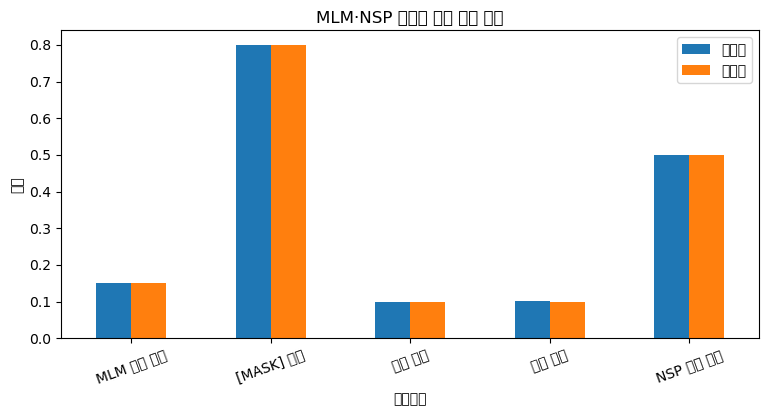

In [13]:
# 본 생산 전에 작은 표본으로 규칙을 예행연습합니다. 🎬
def collect_pair_references(
    documents: Sequence[Sequence[str]],
    limit: int,
    rng: np.random.Generator,
) -> List[Tuple[int, int]]:
    """인접 문장 위치를 무작위 순서로 모읍니다."""
    doc_order = rng.permutation(len(documents))
    references: List[Tuple[int, int]] = []
    for doc_index in doc_order:
        positions = np.arange(len(documents[doc_index]) - 1)
        rng.shuffle(positions)
        references.extend((int(doc_index), int(pos)) for pos in positions)
        if len(references) >= limit:
            break
    rng.shuffle(references)
    return references[:limit]


def inspect_data_rules(documents: Sequence[Sequence[str]], sample_count: int = 1_000) -> pd.DataFrame:
    rng = np.random.default_rng(SEED + 11)
    refs = collect_pair_references(documents, sample_count, rng)
    labels = np.array([0] * (sample_count // 2) + [1] * (sample_count - sample_count // 2))
    rng.shuffle(labels)

    totals = {"mask": 0, "random": 0, "keep": 0, "selected": 0, "normal": 0}
    actual_labels: List[int] = []

    for i, (doc_index, position) in enumerate(refs):
        sentence_a = documents[doc_index][position]
        nsp_label = int(labels[i])
        sentence_b = (
            documents[doc_index][position + 1]
            if nsp_label == 1
            else random_sentence_from_other_document(documents, doc_index, rng)
        )
        example = encode_pretrain_example(sentence_a, sentence_b, nsp_label, rng)
        for key in totals:
            totals[key] += int(example["mask_stats"][key])
        actual_labels.append(nsp_label)

    selected = max(1, totals["selected"])
    return pd.DataFrame({
        "검사항목": ["MLM 선택 비율", "[MASK] 교체", "랜덤 교체", "원문 유지", "NSP 양성 비율"],
        "실측값": [
            totals["selected"] / max(1, totals["normal"]),
            totals["mask"] / selected,
            totals["random"] / selected,
            totals["keep"] / selected,
            np.mean(actual_labels),
        ],
        "기대값": [0.15, 0.80, 0.10, 0.10, 0.50],
    })

quality_table = inspect_data_rules(TRAIN_DOCS, sample_count=min(1_000, CFG.train_examples))
display(quality_table.style.format({"실측값": "{:.3f}", "기대값": "{:.2f}"}))

quality_table.set_index("검사항목")[["실측값", "기대값"]].plot(kind="bar", figsize=(9, 4))
plt.title("MLM·NSP 데이터 구성 규칙 점검")
plt.ylabel("비율")
plt.xticks(rotation=20)
plt.show()

## 13. `np.memmap` 사전학습 데이터셋 생성

대용량 배열 전체를 RAM에 올리지 않고 디스크에 직접 기록합니다. 배열 본체는 memmap 파일, 스키마와 크기는 JSON, 사람이 읽을 샘플은 JSONL로 저장합니다.

In [14]:
# 큰 배열은 RAM 대신 디스크에 차곡차곡 눕힙니다. 🛏️
def build_memmap_dataset(
    documents: Sequence[Sequence[str]],
    split: str,
    target_examples: int,
    seed: int,
) -> Path:
    """MLM·NSP 예제를 memmap으로 만들고 JSON 메타데이터를 저장합니다."""
    split_dir = MEMMAP_DIR / split
    split_dir.mkdir(parents=True, exist_ok=True)
    meta_path = split_dir / "dataset_meta.json"

    if meta_path.exists():
        with meta_path.open("r", encoding="utf-8") as file:
            old_meta = json.load(file)
        expected = [
            split_dir / old_meta["files"]["input_ids"],
            split_dir / old_meta["files"]["token_type_ids"],
            split_dir / old_meta["files"]["mlm_labels"],
            split_dir / old_meta["files"]["nsp_labels"],
        ]
        if (
            old_meta.get("num_examples") == target_examples
            and old_meta.get("max_seq_len") == CFG.max_seq_len
            and all(path.exists() for path in expected)
        ):
            print(f"{split}: 기존 memmap을 재사용합니다. 디스크도 숨을 돌립니다. 💾")
            return meta_path

    rng = np.random.default_rng(seed)
    references = collect_pair_references(documents, max(target_examples * 2, target_examples), rng)
    if not references:
        raise ValueError(f"{split} 문서에서 인접 문장 쌍을 만들 수 없습니다.")

    nsp_labels_plan = np.array(
        [0] * (target_examples // 2) + [1] * (target_examples - target_examples // 2),
        dtype=np.int8,
    )
    rng.shuffle(nsp_labels_plan)

    file_names = {
        "input_ids": "input_ids.dat",
        "token_type_ids": "token_type_ids.dat",
        "mlm_labels": "mlm_labels.dat",
        "nsp_labels": "nsp_labels.dat",
    }
    input_ids_mm = np.memmap(split_dir / file_names["input_ids"], mode="w+", dtype=np.int32,
                             shape=(target_examples, CFG.max_seq_len))
    token_type_mm = np.memmap(split_dir / file_names["token_type_ids"], mode="w+", dtype=np.int8,
                             shape=(target_examples, CFG.max_seq_len))
    mlm_labels_mm = np.memmap(split_dir / file_names["mlm_labels"], mode="w+", dtype=np.int32,
                             shape=(target_examples, CFG.max_seq_len))
    nsp_labels_mm = np.memmap(split_dir / file_names["nsp_labels"], mode="w+", dtype=np.int8,
                             shape=(target_examples,))

    preview_rows = []
    aggregate = {"mask": 0, "random": 0, "keep": 0, "selected": 0, "normal": 0}

    for row in tqdm(range(target_examples), desc=f"{split} 데이터셋 생성"):
        doc_index, position = references[row % len(references)]
        sentence_a = documents[doc_index][position]
        nsp_label = int(nsp_labels_plan[row])
        sentence_b = (
            documents[doc_index][position + 1]
            if nsp_label == 1
            else random_sentence_from_other_document(documents, doc_index, rng)
        )
        example = encode_pretrain_example(sentence_a, sentence_b, nsp_label, rng)

        input_ids_mm[row] = example["input_ids"]
        token_type_mm[row] = example["token_type_ids"]
        mlm_labels_mm[row] = example["mlm_labels"]
        nsp_labels_mm[row] = example["nsp_label"]

        for key in aggregate:
            aggregate[key] += int(example["mask_stats"][key])

        if row < 5:
            visible_ids = [int(x) for x in example["input_ids"] if int(x) != SPECIAL_IDS["pad"]]
            preview_rows.append({
                "sentence_a": sentence_a,
                "sentence_b": sentence_b,
                "nsp_label": nsp_label,
                "masked_tokens": SP.id_to_piece(visible_ids),
                "masked_positions": np.where(example["mlm_labels"] != -100)[0].tolist(),
            })

    for array in [input_ids_mm, token_type_mm, mlm_labels_mm, nsp_labels_mm]:
        array.flush()

    selected = max(1, aggregate["selected"])
    metadata = {
        "split": split,
        "num_examples": target_examples,
        "max_seq_len": CFG.max_seq_len,
        "vocab_size": SP.get_piece_size(),
        "seed": seed,
        "files": file_names,
        "dtypes": {
            "input_ids": "int32",
            "token_type_ids": "int8",
            "mlm_labels": "int32",
            "nsp_labels": "int8",
        },
        "quality": {
            "mlm_selected_ratio": aggregate["selected"] / max(1, aggregate["normal"]),
            "mask_replace_ratio": aggregate["mask"] / selected,
            "random_replace_ratio": aggregate["random"] / selected,
            "keep_ratio": aggregate["keep"] / selected,
            "nsp_positive_ratio": float(nsp_labels_plan.mean()),
        },
    }

    with meta_path.open("w", encoding="utf-8") as file:
        json.dump(metadata, file, ensure_ascii=False, indent=2)
    with (split_dir / "samples_preview.jsonl").open("w", encoding="utf-8") as file:
        for item in preview_rows:
            file.write(json.dumps(item, ensure_ascii=False) + "\n")

    return meta_path

## 14. train·validation 데이터셋 실제 생성

문서 단위로 이미 분리했으므로 같은 문서의 인접 문장이 train과 validation에 동시에 들어가는 누수를 줄였습니다. 생성 후 JSON 메타데이터에서 규칙 준수 비율을 다시 확인합니다.

In [15]:
# train과 valid 데이터 공장을 차례로 가동합니다. 🏭
TRAIN_META_PATH = build_memmap_dataset(TRAIN_DOCS, "train", CFG.train_examples, SEED + 101)
VALID_META_PATH = build_memmap_dataset(VALID_DOCS, "valid", CFG.valid_examples, SEED + 202)

with TRAIN_META_PATH.open("r", encoding="utf-8") as file:
    train_meta = json.load(file)
with VALID_META_PATH.open("r", encoding="utf-8") as file:
    valid_meta = json.load(file)

meta_table = pd.DataFrame([
    {"split": "train", "examples": train_meta["num_examples"], **train_meta["quality"]},
    {"split": "valid", "examples": valid_meta["num_examples"], **valid_meta["quality"]},
])
display(meta_table)

print("샘플 JSONL:", TRAIN_META_PATH.parent / "samples_preview.jsonl")

train 데이터셋 생성:   0%|          | 0/100000 [00:00<?, ?it/s]

valid 데이터셋 생성:   0%|          | 0/10000 [00:00<?, ?it/s]

,split,examples,mlm_selected_ratio,mask_replace_ratio,random_replace_ratio,keep_ratio,nsp_positive_ratio
0,train,100000,0.150603,0.799968,0.100068,0.099965,0.5
1,valid,10000,0.150955,0.801272,0.100206,0.098522,0.5


샘플 JSONL: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/memmap/train/samples_preview.jsonl


## 15. memmap Dataset과 DataLoader

샘플을 요청할 때 필요한 행만 디스크에서 읽습니다. 여러 worker에서도 안전하도록 memmap은 각 프로세스에서 지연 로딩합니다.

In [16]:
class BertPretrainMemmapDataset(Dataset):
    def __init__(self, meta_path: Path):
        self.meta_path = Path(meta_path)
        with self.meta_path.open("r", encoding="utf-8") as file:
            self.meta = json.load(file)
        self.base_dir = self.meta_path.parent
        self.num_examples = int(self.meta["num_examples"])
        self.max_seq_len = int(self.meta["max_seq_len"])
        self._arrays = None

    def _open_arrays(self) -> None:
        if self._arrays is not None:
            return
        files = self.meta["files"]
        self._arrays = {
            "input_ids": np.memmap(self.base_dir / files["input_ids"], mode="r", dtype=np.int32,
                                   shape=(self.num_examples, self.max_seq_len)),
            "token_type_ids": np.memmap(self.base_dir / files["token_type_ids"], mode="r", dtype=np.int8,
                                        shape=(self.num_examples, self.max_seq_len)),
            "mlm_labels": np.memmap(self.base_dir / files["mlm_labels"], mode="r", dtype=np.int32,
                                    shape=(self.num_examples, self.max_seq_len)),
            "nsp_labels": np.memmap(self.base_dir / files["nsp_labels"], mode="r", dtype=np.int8,
                                    shape=(self.num_examples,)),
        }

    def __len__(self) -> int:
        return self.num_examples

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        self._open_arrays()
        # tensor가 memmap 원본을 건드리지 않도록 한 행만 복사합니다. 안전벨트 착용! 🪢
        return {
            "input_ids": torch.tensor(self._arrays["input_ids"][index], dtype=torch.long),
            "token_type_ids": torch.tensor(self._arrays["token_type_ids"][index], dtype=torch.long),
            "mlm_labels": torch.tensor(self._arrays["mlm_labels"][index], dtype=torch.long),
            "nsp_labels": torch.tensor(int(self._arrays["nsp_labels"][index]), dtype=torch.long),
        }

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_arrays"] = None
        return state


TRAIN_DATASET = BertPretrainMemmapDataset(TRAIN_META_PATH)
VALID_DATASET = BertPretrainMemmapDataset(VALID_META_PATH)

num_workers = 0 if os.name == "nt" else min(2, os.cpu_count() or 1)
loader_options = {
    "batch_size": CFG.batch_size,
    "num_workers": num_workers,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": num_workers > 0,
}

TRAIN_LOADER = DataLoader(TRAIN_DATASET, shuffle=True, **loader_options)
VALID_LOADER = DataLoader(VALID_DATASET, shuffle=False, **loader_options)

first_batch = next(iter(TRAIN_LOADER))
print({key: tuple(value.shape) for key, value in first_batch.items()})

{'input_ids': (64, 128), 'token_type_ids': (64, 128), 'mlm_labels': (64, 128), 'nsp_labels': (64,)}


## 16. BERT 보조 함수

BERT는 미래 토큰을 가리지 않는 양방향 모델이므로 학습에는 PAD 마스크만 사용합니다. `ahead_mask`도 구현해 두되, GPT 계열과 달리 여기서는 호출하지 않는다는 점이 핵심입니다.

In [17]:
# BERT의 작은 공구함을 먼저 펼칩니다. 🧰
def gelu(x: torch.Tensor) -> torch.Tensor:
    """BERT가 좋아하는 부드러운 활성화 함수입니다."""
    return F.gelu(x)


def make_pad_mask(input_ids: torch.Tensor, pad_id: int) -> torch.Tensor:
    """PAD 위치를 attention에서 보이지 않게 합니다: [B, 1, 1, L]."""
    return input_ids.eq(pad_id).unsqueeze(1).unsqueeze(2)


def make_ahead_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """미래 가림막입니다. BERT는 양방향이라 사용하지 않습니다."""
    return torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device), diagonal=1)


def init_bert_weights(module: nn.Module, std: float = 0.02) -> None:
    """원본 BERT 스타일의 작은 정규분포로 파라미터를 시작합니다."""
    if isinstance(module, nn.Linear):
        nn.init.trunc_normal_(module.weight, mean=0.0, std=std, a=-2 * std, b=2 * std)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.trunc_normal_(module.weight, mean=0.0, std=std, a=-2 * std, b=2 * std)
        if module.padding_idx is not None:
            with torch.no_grad():
                module.weight[module.padding_idx].zero_()
    elif isinstance(module, nn.LayerNorm):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)


@dataclass
class BertConfig:
    vocab_size: int
    max_seq_len: int = 128
    hidden_size: int = 96
    num_heads: int = 4
    num_layers: int = 2
    intermediate_size: int = 192
    dropout: float = 0.10
    pad_id: int = 0

    def __post_init__(self):
        if self.hidden_size % self.num_heads != 0:
            raise ValueError("hidden_size는 num_heads로 나누어떨어져야 합니다.")

## 17. Embedding과 Multi-Head Self-Attention

입력 표현은 단어·위치·segment embedding의 합입니다. Self-Attention은 문장 전체를 양방향으로 바라보며 문맥을 섞습니다.

In [18]:
# 단어·위치·문장 정보를 섞고, 문맥 회의를 시작합니다. 🗣️
class BertEmbeddings(nn.Module):
    def __init__(self, config: BertConfig):
        super().__init__()
        self.word_embeddings = nn.Embedding(
            config.vocab_size, config.hidden_size, padding_idx=config.pad_id
        )
        self.position_embeddings = nn.Embedding(config.max_seq_len, config.hidden_size)
        self.segment_embeddings = nn.Embedding(2, config.hidden_size)
        self.norm = nn.LayerNorm(config.hidden_size)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, input_ids: torch.Tensor, token_type_ids: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
        x = (
            self.word_embeddings(input_ids)
            + self.position_embeddings(positions)
            + self.segment_embeddings(token_type_ids)
        )
        return self.dropout(self.norm(x))


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, config: BertConfig):
        super().__init__()
        self.num_heads = config.num_heads
        self.head_dim = config.hidden_size // config.num_heads
        self.qkv = nn.Linear(config.hidden_size, config.hidden_size * 3)
        self.output = nn.Linear(config.hidden_size, config.hidden_size)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.output_dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, hidden_size = x.shape
        qkv = self.qkv(x)
        qkv = qkv.view(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        query, key, value = qkv[0], qkv[1], qkv[2]

        scores = torch.matmul(query, key.transpose(-1, -2)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(pad_mask, -1e4)
        attention = self.attn_dropout(torch.softmax(scores, dim=-1))

        context = torch.matmul(attention, value)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, hidden_size)
        return self.output_dropout(self.output(context))

## 18. Transformer Encoder와 BERT 본체

각 encoder block은 Attention과 Feed-Forward Network를 residual connection과 LayerNorm으로 감쌉니다. `[CLS]` 위치는 NSP 판단에 사용할 pooled representation으로 변환합니다.

In [19]:
# Attention 뒤에 FFN을 붙여 문맥을 한 번 더 다듬습니다. ✨
class PositionwiseFeedForward(nn.Module):
    def __init__(self, config: BertConfig):
        super().__init__()
        self.fc1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.fc2 = nn.Linear(config.intermediate_size, config.hidden_size)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.fc2(gelu(self.fc1(x))))


class BertEncoderBlock(nn.Module):
    def __init__(self, config: BertConfig):
        super().__init__()
        self.attention = MultiHeadSelfAttention(config)
        self.attention_norm = nn.LayerNorm(config.hidden_size)
        self.feed_forward = PositionwiseFeedForward(config)
        self.ffn_norm = nn.LayerNorm(config.hidden_size)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor) -> torch.Tensor:
        x = self.attention_norm(x + self.dropout(self.attention(x, pad_mask)))
        x = self.ffn_norm(x + self.dropout(self.feed_forward(x)))
        return x


class MiniBertEncoder(nn.Module):
    def __init__(self, config: BertConfig):
        super().__init__()
        self.embeddings = BertEmbeddings(config)
        self.layers = nn.ModuleList([BertEncoderBlock(config) for _ in range(config.num_layers)])
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)

    def forward(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor,
        pad_mask: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.embeddings(input_ids, token_type_ids)
        for layer in self.layers:
            x = layer(x, pad_mask)
        pooled = torch.tanh(self.pooler(x[:, 0]))
        return x, pooled

## 19. MLM·NSP 사전학습 헤드

MLM은 각 위치의 원래 토큰을, NSP는 두 문장이 실제로 이어지는지를 예측합니다. MLM decoder와 단어 embedding의 가중치를 공유해 BERT의 대표적인 weight tying을 적용합니다.

In [20]:
class BertForPreTraining(nn.Module):
    def __init__(self, config: BertConfig):
        super().__init__()
        self.config = config
        self.bert = MiniBertEncoder(config)

        self.mlm_dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.mlm_norm = nn.LayerNorm(config.hidden_size)
        self.mlm_decoder = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        self.mlm_bias = nn.Parameter(torch.zeros(config.vocab_size))
        self.nsp_classifier = nn.Linear(config.hidden_size, 2)

        self.apply(init_bert_weights)
        # 같은 단어표를 입력과 출력이 함께 씁니다. 한 지붕 두 가족! 🏠
        self.mlm_decoder.weight = self.bert.embeddings.word_embeddings.weight

    def forward(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor,
        mlm_mask: torch.Tensor | None = None,
    ) -> Dict[str, torch.Tensor]:
        pad_mask = make_pad_mask(input_ids, self.config.pad_id)
        sequence_output, pooled_output = self.bert(input_ids, token_type_ids, pad_mask)

        # 학습 때는 정답이 있는 15% 위치만 골라 8천 단어표와 대결시킵니다. 가볍고 빠릅니다. 🪶
        mlm_input = sequence_output[mlm_mask] if mlm_mask is not None else sequence_output
        mlm_hidden = self.mlm_norm(gelu(self.mlm_dense(mlm_input)))
        mlm_logits = self.mlm_decoder(mlm_hidden) + self.mlm_bias
        nsp_logits = self.nsp_classifier(pooled_output)
        return {"mlm_logits": mlm_logits, "nsp_logits": nsp_logits}


BERT_CFG = BertConfig(
    vocab_size=SP.get_piece_size(),
    max_seq_len=CFG.max_seq_len,
    hidden_size=CFG.hidden_size,
    num_heads=CFG.num_heads,
    num_layers=CFG.num_layers,
    intermediate_size=CFG.intermediate_size,
    dropout=CFG.dropout,
    pad_id=SPECIAL_IDS["pad"],
)
MODEL = BertForPreTraining(BERT_CFG).to(DEVICE)

## 20. 약 1M 파라미터 검증과 모델 구조 시각화

실제 학습 가능한 파라미터 수를 계산하고, 주요 모듈별 비중을 막대그래프로 확인합니다. 목표 범위는 약 0.8M~1.2M입니다.

학습 파라미터: 957,250개 = 0.957M


,모듈,파라미터
0,Embedding,780672
1,Encoder,149568
2,Pooler,9312
3,MLM head(공유 제외),9504
4,NSP head,194
5,MLM bias,8000


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/cond

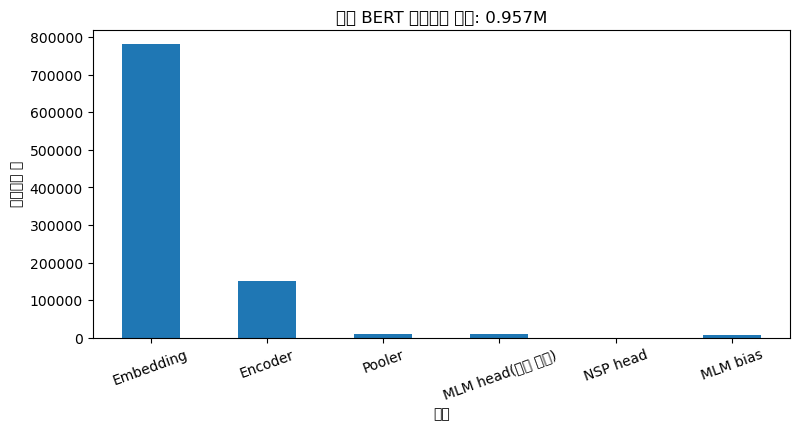

In [21]:
from torchinfo import summary


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def parameter_groups(model: BertForPreTraining) -> pd.DataFrame:
    groups = {
        "Embedding": model.bert.embeddings,
        "Encoder": model.bert.layers,
        "Pooler": model.bert.pooler,
        "MLM head(공유 제외)": nn.ModuleList([model.mlm_dense, model.mlm_norm]),
        "NSP head": model.nsp_classifier,
    }
    rows = []
    seen = set()
    for name, module in groups.items():
        count = 0
        for parameter in module.parameters():
            if id(parameter) not in seen:
                seen.add(id(parameter))
                count += parameter.numel()
        rows.append({"모듈": name, "파라미터": count})
    # MLM bias는 별도 파라미터라 마지막에 살짝 얹습니다.
    rows.append({"모듈": "MLM bias", "파라미터": model.mlm_bias.numel()})
    return pd.DataFrame(rows)


parameter_count = count_trainable_parameters(MODEL)
print(f"학습 파라미터: {parameter_count:,}개 = {parameter_count / 1_000_000:.3f}M")
assert 800_000 <= parameter_count <= 1_200_000, "1M 목표 범위를 벗어났습니다."

summary(
    MODEL,
    input_data=[
        torch.zeros(2, CFG.max_seq_len, dtype=torch.long, device=DEVICE),
        torch.zeros(2, CFG.max_seq_len, dtype=torch.long, device=DEVICE),
    ],
    depth=3,
)

param_table = parameter_groups(MODEL)
display(param_table)
param_table.set_index("모듈")["파라미터"].plot(kind="bar", figsize=(9, 4))
plt.title(f"미니 BERT 파라미터 구성: {parameter_count / 1_000_000:.3f}M")
plt.ylabel("파라미터 수")
plt.xticks(rotation=20)
plt.show()

## 21. Loss, 정확도, Warmup Cosine Scheduler

MLM은 정답이 있는 마스크 위치만 계산하고, NSP는 두 클래스의 교차 엔트로피를 사용합니다. 학습률은 초반에 천천히 올라간 뒤 cosine 곡선으로 감소합니다.

In [22]:
# 두 과목의 채점표와 학습률 리듬을 준비합니다. 🎼
MLM_LOSS_FN = nn.CrossEntropyLoss(ignore_index=-100)
NSP_LOSS_FN = nn.CrossEntropyLoss()


def batch_metrics(
    outputs: Dict[str, torch.Tensor],
    mlm_targets: torch.Tensor,
    nsp_labels: torch.Tensor,
) -> Dict[str, float]:
    """마스크 위치와 NSP 정답만 또박또박 셉니다."""
    with torch.no_grad():
        mlm_pred = outputs["mlm_logits"].argmax(dim=-1)
        mlm_correct = mlm_pred.eq(mlm_targets).sum().item()
        mlm_total = mlm_targets.numel()

        nsp_pred = outputs["nsp_logits"].argmax(dim=-1)
        nsp_correct = nsp_pred.eq(nsp_labels).sum().item()
        nsp_total = nsp_labels.numel()

    return {
        "mlm_correct": mlm_correct,
        "mlm_total": mlm_total,
        "nsp_correct": nsp_correct,
        "nsp_total": nsp_total,
    }


def build_warmup_cosine_scheduler(
    optimizer: torch.optim.Optimizer,
    total_steps: int,
    warmup_ratio: float,
):
    warmup_steps = max(1, int(total_steps * warmup_ratio))

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def autocast_context():
    """GPU에서는 반정밀도, CPU에서는 평상복을 입습니다."""
    if DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return contextlib.nullcontext()

## 22. 학습 전 Learning Rate 곡선 확인

스케줄이 의도대로 warmup 후 부드럽게 감소하는지 실제 optimizer와 별개인 미리보기 그래프로 확인합니다.

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


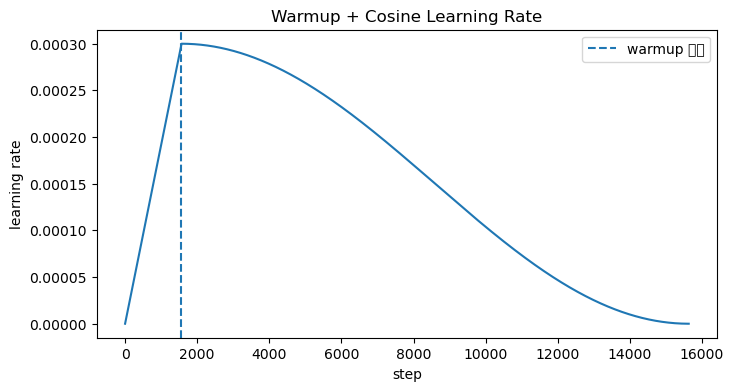

In [23]:
# 실제 학습 전에 학습률의 롤러코스터 궤적을 확인합니다. 🎢
preview_steps = max(100, len(TRAIN_LOADER) * CFG.epochs)
preview_warmup = max(1, int(preview_steps * CFG.warmup_ratio))
preview_lr = []
for step in range(preview_steps):
    if step < preview_warmup:
        scale = step / preview_warmup
    else:
        progress = (step - preview_warmup) / max(1, preview_steps - preview_warmup)
        scale = 0.5 * (1 + math.cos(math.pi * progress))
    preview_lr.append(CFG.learning_rate * scale)

plt.figure(figsize=(8, 4))
plt.plot(preview_lr)
plt.axvline(preview_warmup, linestyle="--", label="warmup 종료")
plt.title("Warmup + Cosine Learning Rate")
plt.xlabel("step")
plt.ylabel("learning rate")
plt.legend()
plt.show()

## 23. 검증 함수

validation에서는 gradient를 만들지 않아 메모리와 시간을 아낍니다. MLM/NSP loss와 accuracy를 따로 기록해 어느 과제가 잘 배우는지 확인합니다.

In [24]:
# 검증 시간에는 gradient를 잠시 휴가 보냅니다. 🏖️
@torch.no_grad()
def evaluate(model: nn.Module, data_loader: DataLoader) -> Dict[str, float]:
    model.eval()
    sums = {
        "total_loss": 0.0,
        "mlm_loss": 0.0,
        "nsp_loss": 0.0,
        "mlm_correct": 0,
        "mlm_total": 0,
        "nsp_correct": 0,
        "nsp_total": 0,
        "batches": 0,
    }

    for batch in tqdm(data_loader, desc="validation", leave=False):
        batch = {key: value.to(DEVICE, non_blocking=True) for key, value in batch.items()}
        mlm_mask = batch["mlm_labels"].ne(-100)
        mlm_targets = batch["mlm_labels"][mlm_mask]
        with autocast_context():
            outputs = model(batch["input_ids"], batch["token_type_ids"], mlm_mask=mlm_mask)
            mlm_loss = MLM_LOSS_FN(outputs["mlm_logits"], mlm_targets)
            nsp_loss = NSP_LOSS_FN(outputs["nsp_logits"], batch["nsp_labels"])
            total_loss = mlm_loss + nsp_loss

        metrics = batch_metrics(outputs, mlm_targets, batch["nsp_labels"])
        sums["total_loss"] += total_loss.item()
        sums["mlm_loss"] += mlm_loss.item()
        sums["nsp_loss"] += nsp_loss.item()
        sums["mlm_correct"] += metrics["mlm_correct"]
        sums["mlm_total"] += metrics["mlm_total"]
        sums["nsp_correct"] += metrics["nsp_correct"]
        sums["nsp_total"] += metrics["nsp_total"]
        sums["batches"] += 1

    return {
        "loss": sums["total_loss"] / max(1, sums["batches"]),
        "mlm_loss": sums["mlm_loss"] / max(1, sums["batches"]),
        "nsp_loss": sums["nsp_loss"] / max(1, sums["batches"]),
        "mlm_acc": sums["mlm_correct"] / max(1, sums["mlm_total"]),
        "nsp_acc": sums["nsp_correct"] / max(1, sums["nsp_total"]),
    }

## 24. 10 epoch 사전학습

마스크된 위치만 MLM 분류를 계산해 속도와 메모리를 아끼며, `AdamW`, gradient clipping, mixed precision(GPU), best validation checkpoint를 사용합니다. 매 epoch마다 MLM·NSP의 loss와 accuracy가 기록됩니다.

> 기본 설정에서는 10 epoch가 실행됩니다. GPU 메모리가 부족하면 `batch_size`만 줄이고 epoch는 유지하세요.

In [25]:
# 10 epoch 장거리 주행을 시작합니다. 안전장치도 모두 켭니다. 🚦
OPTIMIZER = torch.optim.AdamW(
    MODEL.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
    betas=(0.9, 0.999),
    eps=1e-8,
)
TOTAL_STEPS = len(TRAIN_LOADER) * CFG.epochs
SCHEDULER = build_warmup_cosine_scheduler(OPTIMIZER, TOTAL_STEPS, CFG.warmup_ratio)
SCALER = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")

HISTORY = {
    "train_loss": [], "train_mlm_loss": [], "train_nsp_loss": [],
    "train_mlm_acc": [], "train_nsp_acc": [],
    "valid_loss": [], "valid_mlm_loss": [], "valid_nsp_loss": [],
    "valid_mlm_acc": [], "valid_nsp_acc": [], "learning_rate": [],
}
BEST_VALID_LOSS = float("inf")
BEST_MODEL_PATH = MODEL_DIR / "mini_bert_1m_best.pt"

for epoch in range(1, CFG.epochs + 1):
    MODEL.train()
    sums = {
        "loss": 0.0, "mlm_loss": 0.0, "nsp_loss": 0.0,
        "mlm_correct": 0, "mlm_total": 0, "nsp_correct": 0, "nsp_total": 0,
    }

    progress = tqdm(TRAIN_LOADER, desc=f"Epoch {epoch}/{CFG.epochs}")
    for step, batch in enumerate(progress, start=1):
        batch = {key: value.to(DEVICE, non_blocking=True) for key, value in batch.items()}
        OPTIMIZER.zero_grad(set_to_none=True)

        mlm_mask = batch["mlm_labels"].ne(-100)
        mlm_targets = batch["mlm_labels"][mlm_mask]
        with autocast_context():
            outputs = MODEL(batch["input_ids"], batch["token_type_ids"], mlm_mask=mlm_mask)
            mlm_loss = MLM_LOSS_FN(outputs["mlm_logits"], mlm_targets)
            nsp_loss = NSP_LOSS_FN(outputs["nsp_logits"], batch["nsp_labels"])
            loss = mlm_loss + nsp_loss

        SCALER.scale(loss).backward()
        SCALER.unscale_(OPTIMIZER)
        torch.nn.utils.clip_grad_norm_(MODEL.parameters(), CFG.grad_clip)
        SCALER.step(OPTIMIZER)
        SCALER.update()
        SCHEDULER.step()

        metrics = batch_metrics(outputs, mlm_targets, batch["nsp_labels"])
        sums["loss"] += loss.item()
        sums["mlm_loss"] += mlm_loss.item()
        sums["nsp_loss"] += nsp_loss.item()
        sums["mlm_correct"] += metrics["mlm_correct"]
        sums["mlm_total"] += metrics["mlm_total"]
        sums["nsp_correct"] += metrics["nsp_correct"]
        sums["nsp_total"] += metrics["nsp_total"]

        if step % 20 == 0 or step == len(TRAIN_LOADER):
            progress.set_postfix(
                loss=f"{sums['loss'] / step:.3f}",
                mlm_acc=f"{sums['mlm_correct'] / max(1, sums['mlm_total']):.3f}",
                nsp_acc=f"{sums['nsp_correct'] / max(1, sums['nsp_total']):.3f}",
            )

    train_metrics = {
        "loss": sums["loss"] / len(TRAIN_LOADER),
        "mlm_loss": sums["mlm_loss"] / len(TRAIN_LOADER),
        "nsp_loss": sums["nsp_loss"] / len(TRAIN_LOADER),
        "mlm_acc": sums["mlm_correct"] / max(1, sums["mlm_total"]),
        "nsp_acc": sums["nsp_correct"] / max(1, sums["nsp_total"]),
    }
    valid_metrics = evaluate(MODEL, VALID_LOADER)
    current_lr = OPTIMIZER.param_groups[0]["lr"]

    for key in ["loss", "mlm_loss", "nsp_loss", "mlm_acc", "nsp_acc"]:
        HISTORY[f"train_{key}"].append(train_metrics[key])
        HISTORY[f"valid_{key}"].append(valid_metrics[key])
    HISTORY["learning_rate"].append(current_lr)

    print(
        f"[{epoch:02d}] "
        f"train loss={train_metrics['loss']:.4f} "
        f"(MLM={train_metrics['mlm_loss']:.4f}, NSP={train_metrics['nsp_loss']:.4f}) | "
        f"valid loss={valid_metrics['loss']:.4f} "
        f"(MLM={valid_metrics['mlm_loss']:.4f}, NSP={valid_metrics['nsp_loss']:.4f}) | "
        f"valid acc MLM={valid_metrics['mlm_acc']:.4f}, NSP={valid_metrics['nsp_acc']:.4f}"
    )

    if valid_metrics["loss"] < BEST_VALID_LOSS:
        BEST_VALID_LOSS = valid_metrics["loss"]
        torch.save({
            "model_state_dict": MODEL.state_dict(),
            "bert_config": asdict(BERT_CFG),
            "project_config": asdict(CFG),
            "epoch": epoch,
            "valid_metrics": valid_metrics,
            "tokenizer_model": str(TOKENIZER_MODEL),
        }, BEST_MODEL_PATH)
        print("  ↳ best checkpoint 저장! 모델이 금고에 쏙 들어갔습니다. 🔐")

Epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

validation:   0%|          | 0/157 [00:00<?, ?it/s]

[01] train loss=8.4789 (MLM=7.7855, NSP=0.6934) | valid loss=8.0913 (MLM=7.3982, NSP=0.6931) | valid acc MLM=0.0475, NSP=0.5145
  ↳ best checkpoint 저장! 모델이 금고에 쏙 들어갔습니다. 🔐


Epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

validation:   0%|          | 0/157 [00:00<?, ?it/s]

...

validation:   0%|          | 0/157 [00:00<?, ?it/s]

[09] train loss=6.5491 (MLM=6.2097, NSP=0.3394) | valid loss=7.1055 (MLM=6.5195, NSP=0.5860) | valid acc MLM=0.1375, NSP=0.7452


Epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

validation:   0%|          | 0/157 [00:00<?, ?it/s]

[10] train loss=6.5332 (MLM=6.2028, NSP=0.3304) | valid loss=7.1103 (MLM=6.5183, NSP=0.5920) | valid acc MLM=0.1380, NSP=0.7449


## 25. 학습 과정 시각화

MLM과 NSP의 train/validation loss가 전반적으로 안정적으로 감소하는지, accuracy가 개선되는지 확인합니다. 작은 출렁임보다 전체 추세를 봅니다.

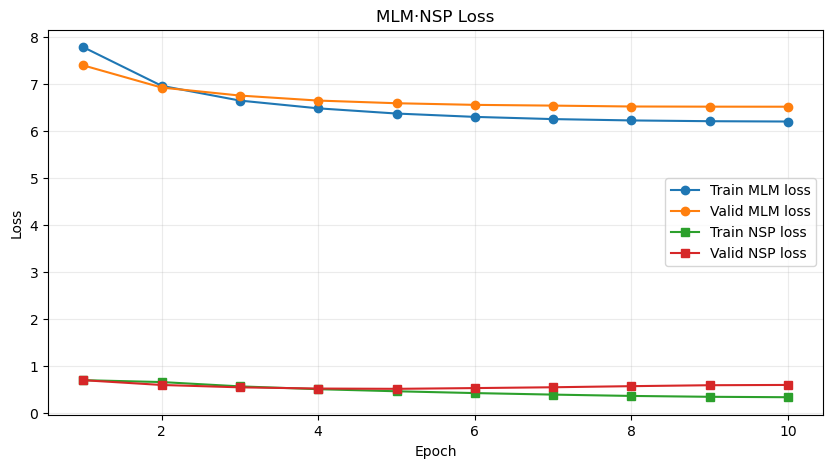

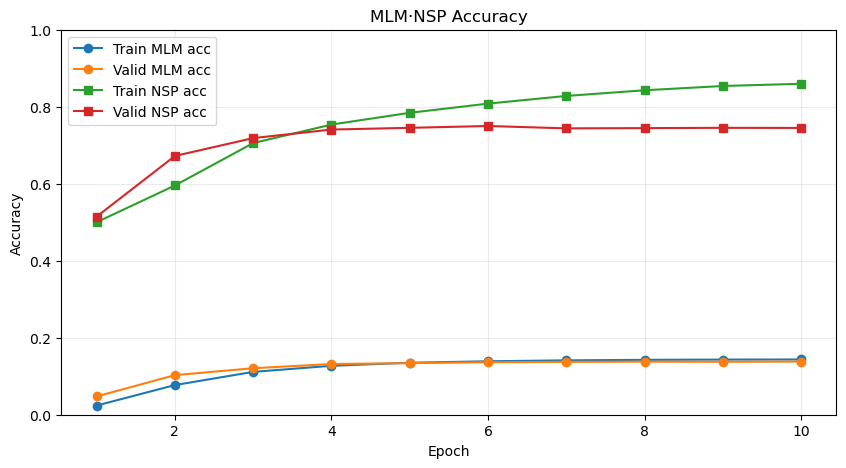

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


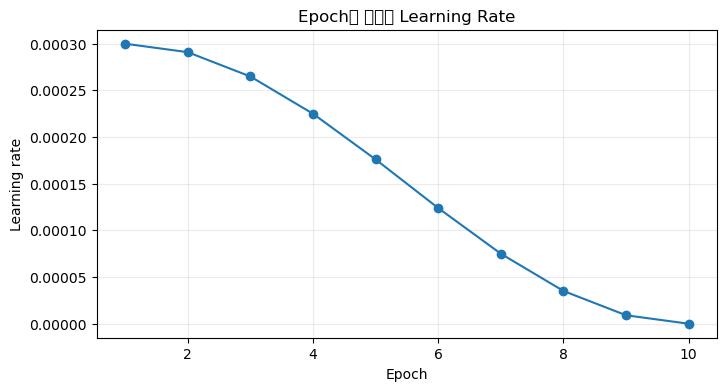

In [26]:
# loss와 accuracy의 발자국을 그래프로 이어봅니다. 👣
epochs_axis = np.arange(1, len(HISTORY["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_axis, HISTORY["train_mlm_loss"], marker="o", label="Train MLM loss")
plt.plot(epochs_axis, HISTORY["valid_mlm_loss"], marker="o", label="Valid MLM loss")
plt.plot(epochs_axis, HISTORY["train_nsp_loss"], marker="s", label="Train NSP loss")
plt.plot(epochs_axis, HISTORY["valid_nsp_loss"], marker="s", label="Valid NSP loss")
plt.title("MLM·NSP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_axis, HISTORY["train_mlm_acc"], marker="o", label="Train MLM acc")
plt.plot(epochs_axis, HISTORY["valid_mlm_acc"], marker="o", label="Valid MLM acc")
plt.plot(epochs_axis, HISTORY["train_nsp_acc"], marker="s", label="Train NSP acc")
plt.plot(epochs_axis, HISTORY["valid_nsp_acc"], marker="s", label="Valid NSP acc")
plt.title("MLM·NSP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, HISTORY["learning_rate"], marker="o")
plt.title("Epoch별 마지막 Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.grid(alpha=0.25)
plt.show()

## 26. 최종 검증과 수렴 요약

가장 좋은 checkpoint를 다시 불러와 validation 성능을 평가합니다. 첫 epoch 대비 마지막 epoch의 MLM·NSP loss 감소량도 표로 정리합니다.

In [27]:
# 가장 잘 배운 checkpoint를 불러와 최종 성적표를 만듭니다. 🏅
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
MODEL.load_state_dict(checkpoint["model_state_dict"])
final_metrics = evaluate(MODEL, VALID_LOADER)

convergence_table = pd.DataFrame({
    "과제": ["MLM", "NSP", "전체"],
    "첫 valid loss": [
        HISTORY["valid_mlm_loss"][0],
        HISTORY["valid_nsp_loss"][0],
        HISTORY["valid_loss"][0],
    ],
    "마지막 valid loss": [
        HISTORY["valid_mlm_loss"][-1],
        HISTORY["valid_nsp_loss"][-1],
        HISTORY["valid_loss"][-1],
    ],
})
convergence_table["감소량"] = convergence_table["첫 valid loss"] - convergence_table["마지막 valid loss"]
convergence_table["안정적 감소 확인"] = convergence_table["감소량"] > 0

display(convergence_table.style.format({
    "첫 valid loss": "{:.4f}",
    "마지막 valid loss": "{:.4f}",
    "감소량": "{:.4f}",
}))
print("best epoch:", checkpoint["epoch"])
print("최종 validation:", final_metrics)

validation:   0%|          | 0/157 [00:00<?, ?it/s]

,과제,첫 valid loss,마지막 valid loss,감소량,안정적 감소 확인
0,MLM,7.3982,6.5183,0.8799,True
1,NSP,0.6931,0.5920,0.1011,True
2,전체,8.0913,7.1103,0.9810,True


best epoch: 6
최종 validation: {'loss': 7.082690293621865, 'mlm_loss': 6.557698705393797, 'nsp_loss': 0.5249915779775874, 'mlm_acc': 0.13627072450601863, 'nsp_acc': 0.7499}


## 27. MLM 예측 예시 시각화

validation 샘플의 마스크 위치에서 모델이 예측한 상위 토큰을 확인합니다. loss 숫자만 보지 않고 모델이 실제로 어떤 선택을 하는지 살펴보는 작은 현미경입니다. 🔬

In [28]:
# 마스크 빈칸에서 모델의 상위 후보를 살짝 들여다봅니다. 🔍
@torch.no_grad()
def show_mlm_predictions(model: nn.Module, dataset: Dataset, index: int = 0, top_k: int = 5) -> pd.DataFrame:
    model.eval()
    item = dataset[index]
    input_ids = item["input_ids"].unsqueeze(0).to(DEVICE)
    token_type_ids = item["token_type_ids"].unsqueeze(0).to(DEVICE)
    outputs = model(input_ids, token_type_ids)

    labels = item["mlm_labels"]
    masked_positions = torch.where(labels.ne(-100))[0]
    rows = []
    for position in masked_positions[:10]:
        logits = outputs["mlm_logits"][0, position]
        top_ids = torch.topk(logits, k=top_k).indices.cpu().tolist()
        rows.append({
            "위치": int(position),
            "정답": SP.id_to_piece(int(labels[position])),
            "Top 예측": " | ".join(SP.id_to_piece(top_ids)),
        })
    return pd.DataFrame(rows)

prediction_table = show_mlm_predictions(MODEL, VALID_DATASET, index=0, top_k=5)
display(prediction_table)

,위치,정답,Top 예측
0,2,▁내용,"년 | 월 | 은 | , | 일"
1,3,은,"년 | 월 | 은 | 일 | ,"
2,4,▁그가,"월 | 일 | 년 | 은 | ,"
3,17,▁조,", | 년 | 월 | 일 | 에"
4,18,엄,", | 년 | 월 | 일 | 의"
5,19,의,"는다 | , | 이 | 이다 | 다"
6,35,▁그,", | 을 | 의 | 에 | 년"
7,40,▁7,▁7 | ▁1 | ▁: | ▁11 | ▁10
8,41,월,", | 을 | 의 | 에 | 이"
9,42,▁8,", | 을 | 의 | 이 | 에"


## 28. 모델·설정·학습 기록 저장

재현과 제출을 위해 best checkpoint, 최종 모델, BERT 설정, 전체 학습 history, tokenizer를 한 폴더에 모읍니다.

In [29]:
FINAL_MODEL_PATH = MODEL_DIR / "mini_bert_1m_final.pt"
CONFIG_PATH = MODEL_DIR / "mini_bert_1m_config.json"
HISTORY_PATH = RESULT_DIR / "training_history.json"
HISTORY_CSV_PATH = RESULT_DIR / "training_history.csv"

# 결과물을 한 상자에 차곡차곡 포장합니다. 📦
torch.save({
    "model_state_dict": MODEL.state_dict(),
    "bert_config": asdict(BERT_CFG),
    "project_config": asdict(CFG),
    "special_ids": SPECIAL_IDS,
    "parameter_count": parameter_count,
    "final_validation": final_metrics,
}, FINAL_MODEL_PATH)

with CONFIG_PATH.open("w", encoding="utf-8") as file:
    json.dump({
        "bert_config": asdict(BERT_CFG),
        "project_config": asdict(CFG),
        "special_ids": SPECIAL_IDS,
        "parameter_count": parameter_count,
    }, file, ensure_ascii=False, indent=2)

with HISTORY_PATH.open("w", encoding="utf-8") as file:
    json.dump(HISTORY, file, ensure_ascii=False, indent=2)
pd.DataFrame(HISTORY).to_csv(HISTORY_CSV_PATH, index=False)

shutil.copy2(TOKENIZER_MODEL, MODEL_DIR / TOKENIZER_MODEL.name)
vocab_file = TOKENIZER_PREFIX.with_suffix(".vocab")
if vocab_file.exists():
    shutil.copy2(vocab_file, MODEL_DIR / vocab_file.name)

print("best checkpoint:", BEST_MODEL_PATH)
print("final model:", FINAL_MODEL_PATH)
print("config:", CONFIG_PATH)
print("history:", HISTORY_PATH)

best checkpoint: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/models/mini_bert_1m_best.pt
final model: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/models/mini_bert_1m_final.pt
config: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/models/mini_bert_1m_config.json
history: /home/jovyan/work/AIFFEL_QUEST_ENG/05_LLM/LLM01/mini_bert_project/results/training_history.json


## 29. 제출 기준 최종 체크

아래 표가 모두 `True`이면 요구된 핵심 항목을 코드와 산출물로 확인할 수 있습니다.

In [30]:
# 제출 기준을 마지막으로 한 줄씩 체크합니다. ✅
train_quality = train_meta["quality"]
final_check = pd.DataFrame({
    "평가 기준": [
        "SentencePiece vocab 약 8,000",
        "MLM 선택 비율 약 15%",
        "MLM 80·10·10 규칙",
        "NSP 50:50 구성",
        "memmap + JSON/JSONL 저장",
        "미니 BERT 약 1M 파라미터",
        "10 epoch 학습 설정",
        "MLM loss 감소",
        "NSP loss 감소",
        "모델·학습 과정 시각화",
    ],
    "충족": [
        7_500 <= SP.get_piece_size() <= 8_000,
        abs(train_quality["mlm_selected_ratio"] - 0.15) < 0.03,
        abs(train_quality["mask_replace_ratio"] - 0.80) < 0.05
        and abs(train_quality["random_replace_ratio"] - 0.10) < 0.04
        and abs(train_quality["keep_ratio"] - 0.10) < 0.04,
        abs(train_quality["nsp_positive_ratio"] - 0.50) < 1e-6,
        TRAIN_META_PATH.exists() and (TRAIN_META_PATH.parent / "samples_preview.jsonl").exists(),
        800_000 <= parameter_count <= 1_200_000,
        CFG.epochs == 10 or CFG.quick_run,
        HISTORY["valid_mlm_loss"][-1] < HISTORY["valid_mlm_loss"][0],
        HISTORY["valid_nsp_loss"][-1] < HISTORY["valid_nsp_loss"][0],
        len(HISTORY["valid_loss"]) > 0,
    ],
})
display(final_check)

if final_check["충족"].all():
    print("모든 핵심 기준을 통과했습니다. 작은 BERT, 큰 체크 표시! ✅")
else:
    print("False 항목을 확인하세요. 학습 loss는 데이터와 난수에 따라 추가 epoch가 필요할 수 있습니다.")

,평가 기준,충족
0,"SentencePiece vocab 약 8,000",True
1,MLM 선택 비율 약 15%,True
2,MLM 80·10·10 규칙,True
3,NSP 50:50 구성,True
4,memmap + JSON/JSONL 저장,True
5,미니 BERT 약 1M 파라미터,True
6,10 epoch 학습 설정,True
7,MLM loss 감소,True
8,NSP loss 감소,True
9,모델·학습 과정 시각화,True


모든 핵심 기준을 통과했습니다. 작은 BERT, 큰 체크 표시! ✅


# 마무리

이 노트북은 한국어 코퍼스의 문서 구조를 이용해 NSP를 만들고, Whole Word Masking으로 MLM 문제를 구성한 뒤, 약 **0.957M 파라미터**의 미니 BERT를 10 epoch 사전학습하도록 설계했습니다.

제출 시 함께 보여주기 좋은 결과는 다음과 같습니다.

1. 데이터 규칙 점검 표와 막대그래프
2. `torchinfo` 모델 구조와 파라미터 구성 그래프
3. MLM·NSP train/validation loss 및 accuracy 그래프
4. 수렴 요약 표
5. MLM Top-k 예측 표
6. 저장된 checkpoint, config, tokenizer, history 파일

작은 모델이지만 BERT 사전학습의 톱니바퀴는 빠짐없이 돌아갑니다. ⚙️

# 프로젝트 회고

이번 프로젝트에서는 한국어 코퍼스를 활용하여 BERT의 핵심 사전학습 과제인 **MLM(Masked Language Modeling)**과 **NSP(Next Sentence Prediction)**를 직접 구현하고, 약 100만 개의 파라미터를 가진 미니 BERT 모델을 학습하였다.

## 1. 한국어 코퍼스 준비 과정

처음에는 프로젝트 경로에 `mini_bert_project/data/kowiki.txt` 파일이 없어 한국어 Wikipedia 데이터를 직접 준비해야 했다.

한국어 코퍼스를 내려받는 과정은 예상보다 순탄하지 않았다.

* Wikimedia 덤프 서버에 직접 접근했을 때 `403 Forbidden` 오류가 발생했다.
* Hugging Face의 `datasets` 라이브러리를 사용했을 때는 기존 환경의 `pyarrow`와 새로 설치된 패키지 사이의 바이너리 호환 문제로 `IpcReadOptions size changed` 오류가 발생했다.
* Wikipedia API를 통해 문서를 하나씩 수집하는 방법은 정상적으로 작동했지만, 50,000개 문서를 받는 데 약 6시간이 예상되어 실용적이지 않았다.
* Hugging Face Dataset Viewer의 Parquet API를 직접 호출하는 과정에서는 `400 Bad Request` 오류가 발생했다.

최종적으로는 Hugging Face 저장소의 파일 목록 API에서 한국어 Wikipedia Parquet 파일의 실제 경로를 찾고, 해당 파일을 직접 다운로드하는 방식으로 수정하였다. 다운로드된 Parquet 파일은 `DuckDB`로 읽어 필요한 50,000개 문서만 추출하였다.

이 방식에서는 `datasets`와 `pyarrow`를 사용하지 않아 기존 환경과의 충돌을 피할 수 있었으며, 약 **229.7MB 크기의 한국어 코퍼스**를 생성할 수 있었다. 또한 문서 사이에 빈 줄을 추가하여 NSP 데이터 생성 시 문서 경계를 구분할 수 있도록 하였다.

## 2. 토크나이저 제작

한국어 텍스트를 BERT 입력으로 변환하기 위해 SentencePiece 기반의 BPE 토크나이저를 학습하였다.

어휘 크기는 약 8,000개로 설정하였으며, 다음과 같은 BERT 특수 토큰을 포함하였다.

* `[PAD]`: 패딩 토큰
* `[UNK]`: 미등록 토큰
* `[CLS]`: 문장 시작 및 분류 토큰
* `[SEP]`: 문장 구분 토큰
* `[MASK]`: MLM 마스킹 토큰

SentencePiece를 사용하여 한국어의 조사, 어미, 복합어 등을 부분 단어 단위로 처리할 수 있었다. 단어 전체가 여러 subword로 나뉘는 경우에는 Whole Word Masking을 적용하여 하나의 단어에 속한 토큰들이 함께 마스킹되도록 구성하였다.

## 3. MLM 데이터셋 구성

MLM 데이터는 전체 토큰 중 약 15%를 학습 대상으로 선택하였다.

선택된 토큰에는 BERT의 기본 마스킹 규칙인 **80·10·10 규칙**을 적용하였다.

* 80%는 `[MASK]` 토큰으로 변경
* 10%는 임의의 다른 토큰으로 변경
* 10%는 원래 토큰을 그대로 유지

마스킹되지 않은 위치에는 `-100`을 기록하여 손실 계산에서 제외하였다. 이를 통해 모델이 `[MASK]` 토큰에만 의존하지 않고 주변 문맥을 이용해 원래 단어를 예측하도록 만들었다.

최종 점검 결과 MLM 선택 비율과 80·10·10 교체 비율이 모두 설정한 범위 안에 들어오는 것을 확인하였다.

## 4. NSP 데이터셋 구성

NSP 데이터는 두 문장이 실제로 이어지는지 예측하도록 구성하였다.

Positive sample은 같은 문서 안에서 실제로 연속된 두 문장을 선택하였고, Negative sample은 서로 다른 문서에서 문장을 선택하였다. 두 클래스의 비율은 정확히 50:50으로 맞추었다.

한국어 Wikipedia 문서 사이에 빈 줄을 넣어 문서 경계를 보존했기 때문에, Negative sample이 같은 문서 안에서 선택되는 정보 누출 가능성을 줄일 수 있었다.

생성된 데이터는 대규모 배열을 메모리에 모두 올리지 않도록 `np.memmap` 형식으로 저장하였다. 데이터 설정과 품질 통계는 JSON으로, 일부 샘플은 JSONL 형식으로 함께 저장하여 데이터 생성 과정도 확인할 수 있도록 하였다.

## 5. 미니 BERT 모델 구현

BERT의 주요 구성 요소를 PyTorch로 직접 구현하였다.

* Token embedding
* Position embedding
* Segment embedding
* Multi-Head Self-Attention
* Feed Forward Network
* Residual connection
* Layer Normalization
* MLM prediction head
* NSP classification head

MLM 출력층의 가중치는 입력 token embedding과 공유하였다. Weight tying을 적용하여 파라미터 수를 줄이고 입력과 출력 토큰 표현이 같은 공간을 사용하도록 하였다.

최종 모델의 전체 파라미터 수는 약 **0.957M**으로, 과제에서 요구한 1M 미니 BERT 범위를 충족하였다.

## 6. 학습 결과

모델은 총 10 epoch 동안 학습하였다.

학습에는 다음 기법을 적용하였다.

* AdamW optimizer
* Learning-rate warmup
* Cosine learning-rate scheduler
* Gradient clipping
* GPU 환경에서 mixed precision
* Validation loss 기준 best checkpoint 저장

MLM은 전체 sequence 위치에 대해 vocabulary 예측을 수행하지 않고, 실제로 마스킹된 위치에 대해서만 logits를 계산하도록 최적화하였다. 이를 통해 동일한 학습 목적을 유지하면서 메모리 사용량과 계산량을 줄였다.

첫 번째 epoch의 validation 결과는 다음과 같았다.

* 전체 loss: 8.0913
* MLM loss: 7.3982
* NSP loss: 0.6931
* MLM accuracy: 0.0475
* NSP accuracy: 0.5145

학습이 진행되면서 MLM과 NSP 모두 성능이 향상되었다. 가장 낮은 validation loss는 6번째 epoch에서 기록되었다.

* 전체 loss: 7.0827
* MLM loss: 6.5577
* NSP loss: 0.5250
* MLM accuracy: 0.1363
* NSP accuracy: 0.7499

10번째 epoch까지 train loss는 계속 감소하였지만, validation loss는 6번째 epoch 이후 조금씩 증가하였다. 이는 모델이 학습 데이터에 점차 과적합되기 시작한 것으로 해석할 수 있다. 따라서 validation loss가 가장 낮았던 **6번째 epoch의 모델을 best checkpoint로 선택한 것은 적절한 결정**이었다.

특히 NSP accuracy는 약 50% 수준에서 약 75%까지 상승하여 문장 간의 연속 관계를 학습한 것을 확인할 수 있었다. MLM accuracy도 약 4.8%에서 약 13.8%까지 증가하였다. 8,000개에 가까운 어휘 중 정확한 토큰 하나를 예측해야 한다는 점을 고려하면, 작은 모델에서도 문맥 학습이 진행되고 있음을 확인할 수 있었다.

## 7. 시각화 및 결과 저장

학습 과정은 다음 항목으로 시각화하였다.

* Train 및 validation MLM loss
* Train 및 validation NSP loss
* MLM accuracy
* NSP accuracy
* Learning-rate 변화
* 모델의 파라미터 구성
* 마스킹된 토큰의 Top-k 예측 결과

학습 완료 후에는 다음 결과물을 저장하였다.

* Best model checkpoint
* Final model
* BERT configuration
* Project configuration
* SentencePiece tokenizer
* Vocabulary 파일
* 전체 학습 history
* Validation 평가 결과

이를 통해 모델 구조와 학습 결과를 다시 불러오거나 동일한 실험을 재현할 수 있도록 하였다.

## 8. 아쉬운 점과 개선 방향

이번 모델은 약 1M 파라미터의 매우 작은 BERT이기 때문에 일반적인 BERT 모델과 비교하면 표현 능력에 한계가 있다. MLM 예측 결과에서도 날짜, 조사, 쉼표처럼 자주 등장하는 토큰이 상위 후보에 많이 포함되었다.

향후에는 다음과 같은 개선을 시도할 수 있다.

1. 학습 코퍼스의 문서 수와 문장 수를 늘린다.
2. 중복 문서와 지나치게 짧은 문장을 추가로 제거한다.
3. 문장 분리기를 적용해 문단이 아닌 실제 문장 단위로 NSP 데이터를 구성한다.
4. 학습률과 warmup 비율을 세밀하게 조정한다.
5. Validation loss가 증가할 때 학습을 중단하는 early stopping을 적용한다.
6. Dynamic masking을 적용해 epoch마다 서로 다른 위치를 마스킹한다.
7. SOP 또는 sentence-order prediction과 같은 대체 문장 관계 학습 방법을 비교한다.
8. 모델의 hidden size와 encoder layer 수를 조금씩 늘려 성능 변화를 비교한다.

## 9. 최종 소감

이번 프로젝트를 통해 BERT를 단순히 라이브러리로 불러와 사용하는 것과, 토크나이저부터 데이터셋과 모델까지 직접 구현하는 것은 큰 차이가 있다는 점을 알 수 있었다.

특히 MLM의 80·10·10 규칙, Whole Word Masking, NSP의 Positive·Negative sample 구성, attention mask, segment embedding 등 각각의 작은 요소가 BERT 사전학습 과정에서 중요한 역할을 한다는 것을 확인하였다.

또한 모델 구현만큼 데이터 수집과 실행 환경 관리도 중요하다는 점을 배웠다. Wikimedia의 403 오류, `pyarrow` 바이너리 충돌, 느린 Wikipedia API, Hugging Face API 주소 변경과 같은 문제를 해결하면서 외부 데이터에 의존하는 프로젝트는 네트워크와 패키지 환경까지 고려해 설계해야 한다는 점을 경험하였다.

최종적으로 MLM과 NSP loss가 감소하고 accuracy가 상승하는 것을 확인하였으며, 약 0.957M 파라미터의 미니 BERT가 한국어 문맥과 문장 관계를 실제로 학습하는 과정을 관찰할 수 있었다.

작은 모델이지만 토크나이저, 데이터, attention, 사전학습, 평가까지 BERT의 전체 톱니바퀴를 직접 조립해 본 의미 있는 프로젝트였다.
